In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import  OneHotEncoder, OrdinalEncoder, LabelEncoder

In [2]:
df = pd.read_csv("../../Data/job_salary_prediction_dataset.csv")

In [4]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [15]:
# OneHotEncoder Nominal 
ohe = OneHotEncoder(categories=[['Yes', "No", "Hybrid"]], sparse_output=False, drop='first')

In [16]:
X = df.drop('salary', axis=1)
y = df['salary']

In [7]:
X.shape, y.shape

((250000, 9), (250000,))

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((200000, 9), (50000, 9), (200000,), (50000,))

In [18]:
ohe.fit_transform(X_train[['remote_work']])

array([[0., 0.],
       [0., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [1., 0.],
       [0., 1.]], shape=(200000, 2))

In [19]:
# fit, fit_transform, transform 
ohe.transform(X_test[['remote_work']])

array([[0., 1.],
       [0., 1.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 1.],
       [1., 0.]], shape=(50000, 2))

In [20]:
ohe.get_feature_names_out()

array(['remote_work_No', 'remote_work_Hybrid'], dtype=object)

In [21]:
ohe.feature_names_in_

array(['remote_work'], dtype=object)

In [23]:
1 #float64

1

In [24]:
# ordinal data 
enc  = OrdinalEncoder()
enc.fit_transform(X_train[['company_size']])

array([[2.],
       [1.],
       [2.],
       ...,
       [1.],
       [2.],
       [3.]], shape=(200000, 1))

In [27]:
enc.categories_

[array(['Enterprise', 'Large', 'Medium', 'Small', 'Startup'], dtype=object)]

In [28]:
enc.get_feature_names_out()

array(['company_size'], dtype=object)

In [29]:
enc.feature_names_in_

array(['company_size'], dtype=object)

In [30]:
enc.inverse_transform([[1], [0]])

array([['Large'],
       ['Enterprise']], dtype=object)

In [31]:
ohe.inverse_transform(
    [[0., 1.],
       [0., 1.],
       [0., 0.]]
       
)

array([['Hybrid'],
       ['Hybrid'],
       ['Yes']], dtype=object)

In [32]:
# LabelEncoder # Target col
enc = LabelEncoder()
enc.fit_transform(X_train['location'])

array([3, 7, 1, ..., 0, 7, 2], shape=(200000,))

In [33]:
enc.classes_

array(['Australia', 'Canada', 'Germany', 'India', 'Netherlands', 'Remote',
       'Singapore', 'Sweden', 'UK', 'USA'], dtype=object)

In [34]:
enc.inverse_transform([2,3,4])

array(['Germany', 'India', 'Netherlands'], dtype=object)

In [ ]:
# standardscaler  

In [35]:
import seaborn as sns

<Axes: ylabel='Density'>

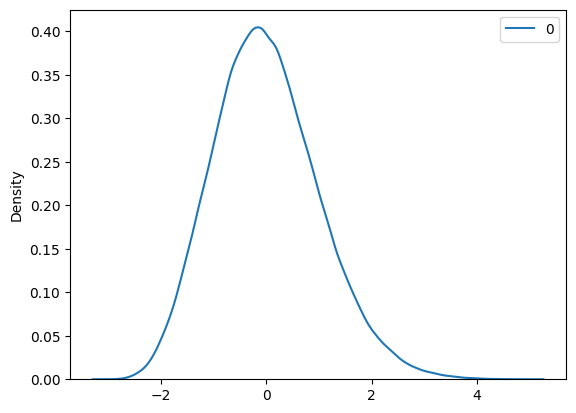

In [49]:
# sns.kdeplot(y_train)
sns.kdeplot(arr)

<Axes: xlabel='salary', ylabel='Density'>

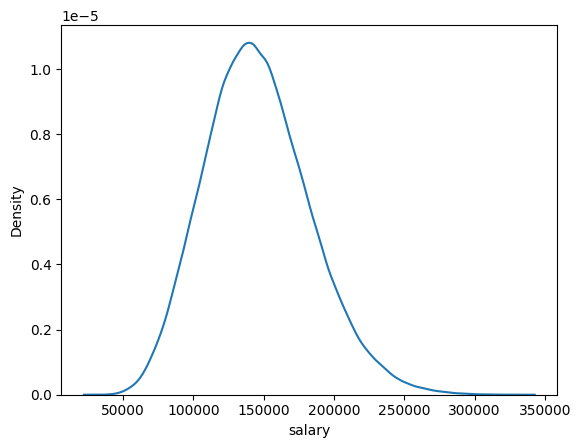

In [51]:
sns.kdeplot(y_train)

In [61]:
from sklearn.preprocessing import StandardScaler, MaxAbsScaler

In [39]:
sc = StandardScaler()

In [41]:
y_train

75381      97647
65569     144887
163473    147645
90518      92191
138866    113442
           ...  
119879     74997
103694    154760
131932    130867
146867     87075
121958    133031
Name: salary, Length: 200000, dtype: int64

In [45]:
pd.DataFrame(y_train)

,salary
75381,97647
65569,144887
163473,147645
90518,92191
138866,113442
...,...
119879,74997
103694,154760
131932,130867
146867,87075


In [47]:
arr = sc.fit_transform(pd.DataFrame(y_train))

In [54]:
# minmaxscaler 
from sklearn.preprocessing import MinMaxScaler, RobustScaler

In [64]:
scale = MinMaxScaler(feature_range=(100, 110))
scale.fit_transform(X_train[['experience_years']])

array([[102. ],
       [100.5],
       [108. ],
       ...,
       [103. ],
       [103.5],
       [106. ]], shape=(200000, 1))

In [57]:
scale = RobustScaler()
arr =scale.fit_transform(X_train[['experience_years']])

<Axes: ylabel='Density'>

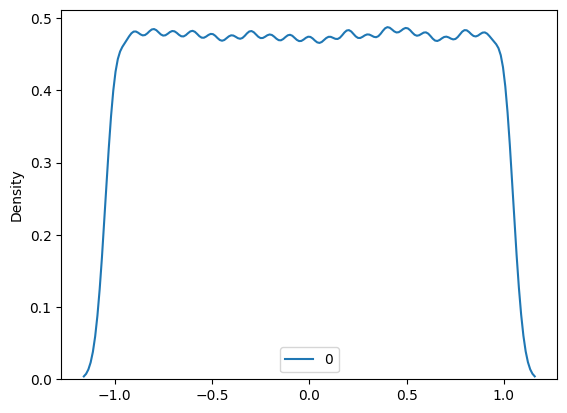

In [58]:
sns.kdeplot(arr)

In [62]:
scale = MaxAbsScaler()
arr =scale.fit_transform(X_train[['experience_years']])

In [63]:
arr

array([[0.2 ],
       [0.05],
       [0.8 ],
       ...,
       [0.3 ],
       [0.35],
       [0.6 ]], shape=(200000, 1))